In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d jessicali9530/celeba-dataset -f img_align_celeba.zip

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
404 Client Error: Not Found for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset


In [ ]:
import os
print(os.listdir("/kaggle/input"))

['celeba-dataset']


In [ ]:
def find_celeba_image_folder(base_dir="/kaggle/input"):
    valid_exts = (".jpg", ".jpeg", ".png", ".webp")

    candidate_dirs = []

    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith(".")]

        image_files = [f for f in files if f.lower().endswith(valid_exts)]
        if len(image_files) > 1000:
            candidate_dirs.append(root)

    preferred = []
    for path in candidate_dirs:
        if "celeba" in path.lower():
            preferred.append(path)

    if preferred:
        return sorted(preferred)[0]

    if candidate_dirs:
        return sorted(candidate_dirs)[0]

    raise FileNotFoundError("No image folder found. Add dataset first.")

In [ ]:
data_root = find_celeba_image_folder()
print("Detected image folder:", data_root)

Detected image folder: /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba


Using device: cuda
Total images loaded: 202599


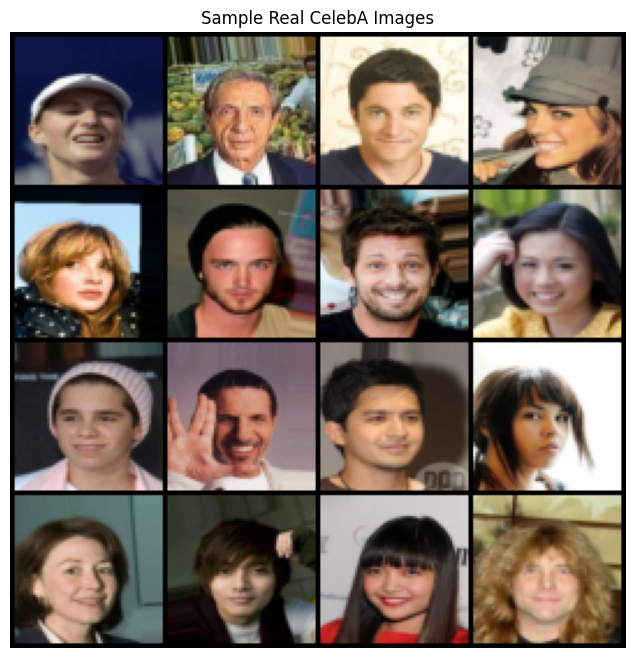

Generator and Discriminator created successfully

Training started...

Epoch [1/30] | D Loss: 0.7039 | G Loss: 2.8615
Epoch [2/30] | D Loss: 1.0767 | G Loss: 1.3469
Epoch [3/30] | D Loss: 0.7170 | G Loss: 2.5795
Epoch [4/30] | D Loss: 0.7555 | G Loss: 2.6182
Epoch [5/30] | D Loss: 1.0850 | G Loss: 4.9593
Epoch [6/30] | D Loss: 0.5405 | G Loss: 4.0151
Epoch [7/30] | D Loss: 0.5617 | G Loss: 3.6411
Epoch [8/30] | D Loss: 0.6519 | G Loss: 4.2536
Epoch [9/30] | D Loss: 0.8141 | G Loss: 1.0282
Epoch [10/30] | D Loss: 0.4712 | G Loss: 3.3521
Epoch [11/30] | D Loss: 0.5564 | G Loss: 2.3662
Epoch [12/30] | D Loss: 0.5174 | G Loss: 4.1099
Epoch [13/30] | D Loss: 4.4194 | G Loss: 0.1898
Epoch [14/30] | D Loss: 0.5239 | G Loss: 3.6183
Epoch [15/30] | D Loss: 0.5211 | G Loss: 2.7870
Epoch [16/30] | D Loss: 0.3969 | G Loss: 3.9788
Epoch [17/30] | D Loss: 0.4584 | G Loss: 3.8617
Epoch [18/30] | D Loss: 0.4667 | G Loss: 3.9608
Epoch [19/30] | D Loss: 0.4521 | G Loss: 4.1794
Epoch [20/30] | D Loss: 0.

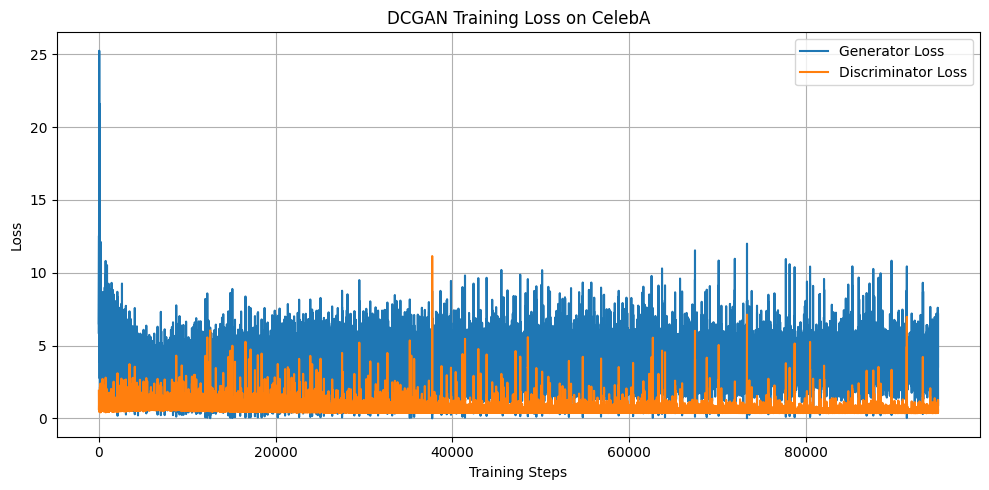

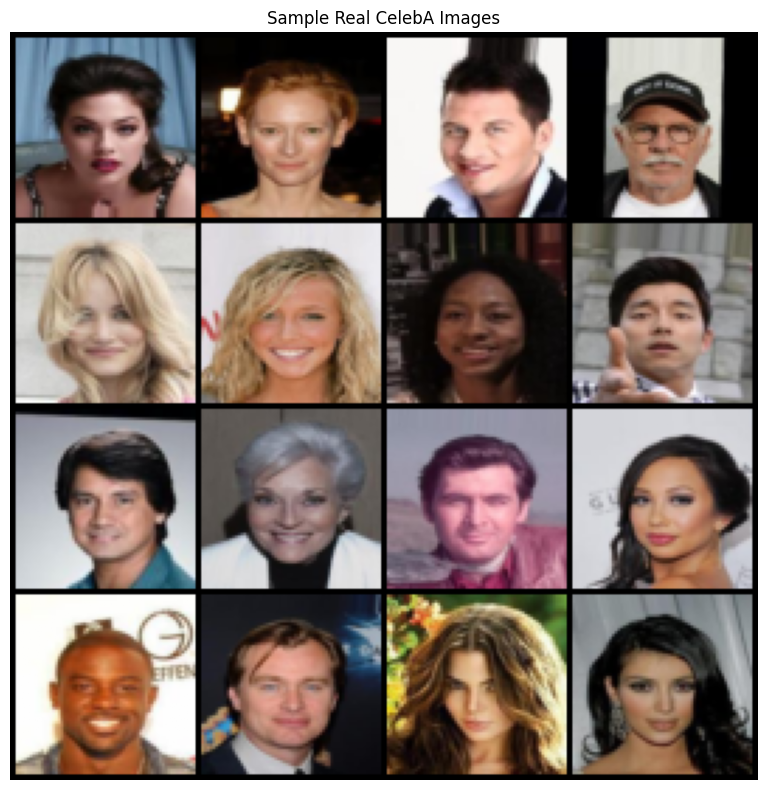


--- Reproducibility Log ---
Image Size : 64
Batch Size : 64
Latent Dim : 100
Epochs     : 30
Learning Rate : 0.0002
Betas      : (0.5, 0.999)
Device     : cuda
Seed       : 42
Dataset    : /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba
Output Dir : /kaggle/working/outputs


In [54]:

# DCGAN for CelebA Face Generation


import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils


# Basic settings

image_size = 64
batch_size = 64
latent_dim = 100
epochs = 30   #  first tested with 10, later change to 30
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

output_dir = "/kaggle/working/outputs"
os.makedirs(output_dir, exist_ok=True)


# Reproducibility

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


# Correct dataset path

data_root = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba"


# Image preprocessing

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])


# Custom dataset

class CelebADataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform

        valid_exts = (".jpg", ".jpeg", ".png")
        self.image_paths = sorted([
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith(valid_exts)
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

dataset = CelebADataset(data_root, transform=transform)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

print("Total images loaded:", len(dataset))


# Show some real images

real_batch = next(iter(loader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Sample Real CelebA Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[:16].cpu(), padding=2, normalize=True, nrow=4),
        (1, 2, 0)
    )
)
plt.show()


# Weight initialisation

def weights_init(m):
    classname = m.__class__.__name__

    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


# Discriminator

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)


# Model setup

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

print("Generator and Discriminator created successfully")


# Loss and optimisers

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)


# Training loop

G_losses = []
D_losses = []

print("\nTraining started...\n")

for epoch in range(epochs):
    for real_images in loader:
        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        # Train discriminator
        optimizer_D.zero_grad()

        real_labels = torch.full((current_batch_size,), 0.9, device=device)
        fake_labels = torch.zeros(current_batch_size, device=device)

        output_real = D(real_images)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(current_batch_size, latent_dim, 1, 1, device=device)
        fake_images = G(noise)

        output_fake = D(fake_images.detach())
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # Train generator
        optimizer_G.zero_grad()

        generator_targets = torch.ones(current_batch_size, device=device)
        output_fake_for_G = D(fake_images)
        loss_G = criterion(output_fake_for_G, generator_targets)

        loss_G.backward()
        optimizer_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

    with torch.no_grad():
        fake_samples = G(fixed_noise).detach().cpu()
        vutils.save_image(
            fake_samples,
            os.path.join(output_dir, f"fake_samples_epoch_{epoch+1:03d}.png"),
            normalize=True,
            nrow=4
        )

print("\nTraining complete!")

# Save final models

torch.save(G.state_dict(), os.path.join(output_dir, "generator_final.pth"))
torch.save(D.state_dict(), os.path.join(output_dir, "discriminator_final.pth"))
print("Final models saved.")


# Save final generated images

with torch.no_grad():
    final_noise = torch.randn(25, latent_dim, 1, 1, device=device)
    final_images = G(final_noise).detach().cpu()

    vutils.save_image(
        final_images,
        os.path.join(output_dir, "final_generated_images.png"),
        normalize=True,
        nrow=5
    )

print("Final generated image grid saved.")

# Training loss plot

plt.figure(figsize=(10, 5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("DCGAN Training Loss on CelebA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "training_curves.png"))
plt.show()


# Save a real image grid for report

real_batch = next(iter(loader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Sample Real CelebA Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[:16].cpu(), padding=2, normalize=True, nrow=4),
        (1, 2, 0)
    )
)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "real_samples.png"))
plt.show()


# Reproducibility log

print("\n--- Reproducibility Log ---")
print("Image Size :", image_size)
print("Batch Size :", batch_size)
print("Latent Dim :", latent_dim)
print("Epochs     :", epochs)
print("Learning Rate :", lr)
print("Betas      :", (beta1, beta2))
print("Device     :", device)
print("Seed       :", seed)
print("Dataset    :", data_root)
print("Output Dir :", output_dir)